In [1]:
import pandas as pd
from tqdm import tqdm
tqdm.pandas()
import numpy as np
import datetime as dt
import math as math
pd.set_option("display.max_columns", None)
from pandas.tseries.offsets import MonthEnd

In [2]:
import_folder_path = r"..\city_lev_output"
output_folder_path = "firm_pca_output"
supporting_folder_path = "supporting_datafiles"

In [3]:
mainFirm = pd.read_pickle(rf"{import_folder_path}\Main_Firm_COMPLETE.pkl")

In [4]:
mainFirm

,FirmID,Symbol,AsOnDate,TotDirCount,AsOnYear,LnBoardSize,FemaleDirCount,PercentWomenDir,Women_dummy,AvgAge,CountRookie,Rookie_dummy,CountNonRookie,CountIndep,PercentIndep,CountNonIndep,CountRookieIndep,CountRookieNonIndep,CountNonRookieIndep,CountNonRookieNonIndep,CountPromoterDir,CountBusyDir,PercentBusyDir,Busy_dummy,HasCeoMD,HasChairman,HasPromoterOnBoard,HasDualityChairmanMD,IsFamilyManaged,HasFamilyChairman,HasFamilyChairmanAndCEO,CountFirstTermDir,CountFirstTermIndepDir,PercentFirstTermIndepDir,CountTurnOverIndepDir,HasIndepTurnOver,AvgTenureInYearsinCompTotal,AvgTenureInYearsinCompIndep,AvgTenureInYearsTotal,PercentRookieIndep,PercentNonRookieIndep,PercentRookieNonIndep,PercentNonRookieNonIndep,PercentRookie,PercentNonRookie,IsRookieBoard,JustOneRookie,TwoOrMoreRookies,CountMBA,PercentMBA,CountIndepMBA,PercentIndepMBA,CountRookieIndepMBA,PercentRookieIndepMBA,CountPhD,PercentPhD,CountIndepPhD,PercentIndepPhD,CountRookieIndepPhD,PercentRookieIndepPhD,CountFinanceXP,PercentFinanceXP,CountIndepFinanceXP,PercentIndepFinanceXP,CountRookieIndepFinanceXP,PercentRookieIndepFinanceXP,CountTechXP,PercentTechXP,CountIndepTechXP,PercentIndepTechXP,CountRookieIndepTechXP,PercentRookieIndepTechXP,CountFinanceSkill,PercentFinanceSkill,CountIndepFinanceSkill,PercentIndepFinanceSkill,CountRookieIndepFinanceSkill,PercentRookieIndepFinanceSkill,CountTechSkill,PercentTechSkill,CountIndepTechSkill,PercentIndepTechSkill,CountRookieIndepTechSkill,PercentRookieIndepTechSkill,CountRelatedIndustryXP,PercentRelatedIndustryXP,CountIndepRelatedIndustryXP,PercentIndepRelatedIndustryXP,CountRookieIndepRelatedIndustryXP,PercentRookieIndepRelatedIndustryXP,CountExecXP,PercentExecXP,CountIndepExecXP,PercentIndepExecXP,CountRookieIndepExecXP,PercentRookieIndepExecXP,CountPublicExecXP,PercentPublicExecXP,CountIndepPublicExecXP,PercentIndepPublicExecXP,CountRookieIndepPublicExecXP,PercentRookieIndepPublicExecXP,CountPrivateExecXP,PercentPrivateExecXP,CountIndepPrivateExecXP,PercentIndepPrivateExecXP,CountRookieIndepPrivateExecXP,PercentRookieIndepPrivateExecXP,CountCeoMDChairXP,PercentCeoMDChairXP,CountIndepCeoMDChairXP,PercentIndepCeoMDChairXP,CountRookieIndepCeoMDChairXP,PercentRookieIndepCeoMDChairXP,CountRookieAppoint,CountRookieIndepAppoint,CountNonRookieAppoint,CountNonRookieIndepAppoint,RookieAppointDummy,RookieIndepAppointDummy,NonRookieAppointDummy,NonRookieIndepAppointDummy,TotalDirCess,TotalRookieIndepDirCess,TotalDirAppoint,TotalRookieIndepDirAppoint,UniqueSkills,CountUniqueSkills,CountRetiringTermLimit,PercentRetiringTermLimit,TermLimitRetireesPcodeList,CountDirTurnOver_exits_retire,PercentDirTurnOver_exits_retire,CountDirTurnOver_real_exits,PercentDirTurnOver_real_exits,CountIndepDirTurnOver_exits_retire,PercentIndepDirTurnOver_exits_retire,CountIndepDirTurnOver_real_exits,PercentIndepDirTurnOver_real_exits,ZeroYearPCodeList,FirstYearPCodeList,TwoYearPCodeList,ThreeYearPCodeList,PCodeList,ZeroYearIndepPCodeList,FirstYearIndepPCodeList,TwoYearIndepPCodeList,ThreeYearIndepPCodeList,IndepPCodeList,BoardAbsenceMean,Academic_mean,Company Business_mean,combined_sustainability_mean,combined_entrepreneurial_mean,combined_compensation_mean,combined_conglomerate_experience_mean,combined_hr_mean,combined_technology_mean,combined_finance_accounting_mean,combined_governance_mean,combined_government_policy_mean,combined_international_mean,combined_leadership_mean,combined_legal_mean,combined_marketing_mean,combined_risk_management_mean,combined_scientific_mean,combined_strategic_planning_mean,combined_manufacturing_supply_chain_mean,combined_leadership_outside_board_mean,skilllist_sustainability_mean,skilllist_entrepreneurial_mean,skilllist_compensation_mean,skilllist_conglomerate_experience_mean,skilllist_hr_mean,skilllist_technology_mean,skilllist_finance_accounting_mean,skilllist_governance_mean,skilllist_government_policy_mean,skilllist_international_mean,skilllist_leadership_mean,skilllist_legal_mean,skilllist_marketing_mean,skilllist_risk_management_

# PCA - skill list

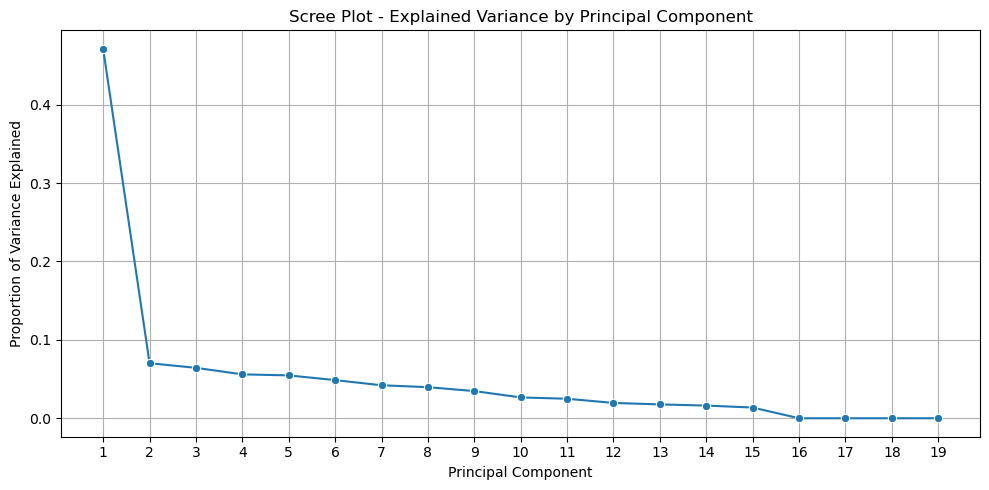

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

skillset_cols = [
     'Academic_mean',
     'Company Business_mean', 
     'skilllist_sustainability_mean',
     'skilllist_entrepreneurial_mean',
     'skilllist_compensation_mean',
     'skilllist_conglomerate_experience_mean',
     'skilllist_hr_mean',
     'skilllist_technology_mean',
     'skilllist_finance_accounting_mean',
     'skilllist_governance_mean',
     'skilllist_government_policy_mean',
     'skilllist_international_mean',
     'skilllist_leadership_mean',
     'skilllist_legal_mean',
     'skilllist_marketing_mean',
     'skilllist_risk_management_mean',
     'skilllist_scientific_mean',
     'skilllist_strategic_planning_mean',
     'skilllist_manufacturing_supply_chain_mean',
]

pcaFiltered = mainFirm.loc[ mainFirm["AsOnYear"] > 2012].copy()

X = pcaFiltered[skillset_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=range(1, len(pca_full.explained_variance_ratio_) + 1),
    y=pca_full.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot - Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

pca = PCA(n_components=3)
principal_component = pca.fit_transform(X_scaled)

pcaFiltered['SkillsetIndex_skillist'] = principal_component[:, 0]
pcaFiltered['SkillsetIndex_skillist'] = (pcaFiltered['SkillsetIndex_skillist'] - pcaFiltered['SkillsetIndex_skillist'].mean()) / pcaFiltered['SkillsetIndex_skillist'].std()

median_value = pcaFiltered['SkillsetIndex_skillist'].median()
pcaFiltered['SkillsetGeneralistDummy_skillist'] = (pcaFiltered['SkillsetIndex_skillist'] > median_value).astype(int)

mainFirm = mainFirm.merge(
    pcaFiltered[['Symbol', 'AsOnDate', 'SkillsetIndex_skillist', 'SkillsetGeneralistDummy_skillist']],
    on=['Symbol', 'AsOnDate'],
    how='left'
)

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(skillset_cols))],
    index=skillset_cols
)

In [6]:
pc1_loadings = loadings[['PC1']].copy()
pc1_loadings['Skillset Feature'] = pc1_loadings.index
pc1_sorted = pc1_loadings.sort_values('PC1', ascending=False)

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_10288\365872179.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')


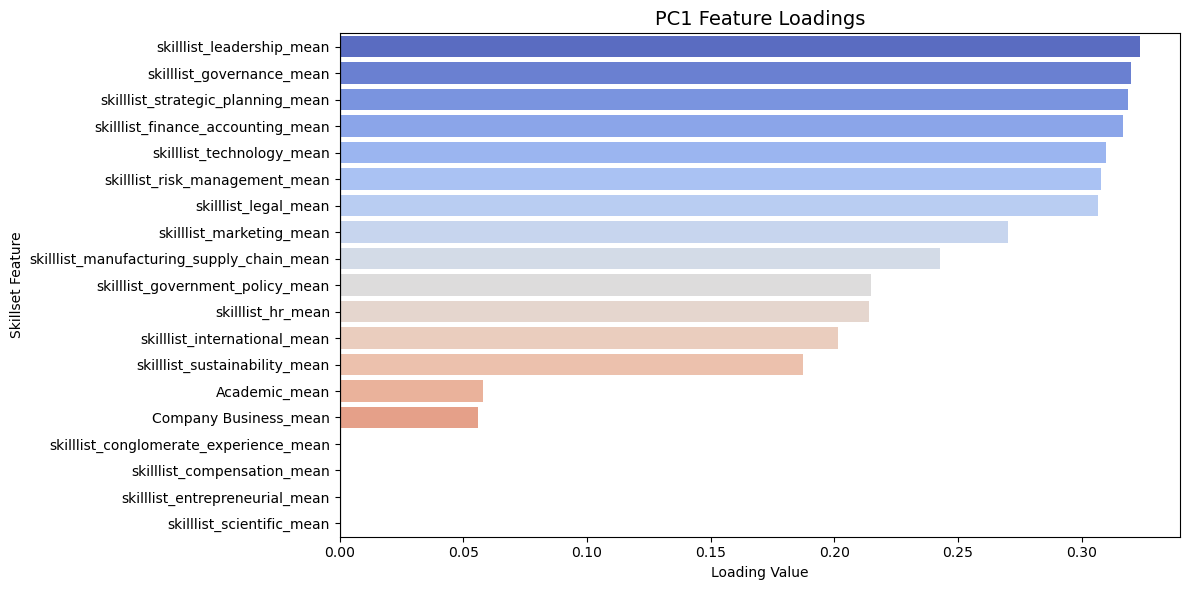

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')
plt.title('PC1 Feature Loadings', fontsize=14)
plt.xlabel('Loading Value')
plt.ylabel('Skillset Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [8]:
eigenvalue_pc1 = pca_full.explained_variance_[0]
explained_variance_ratio_pc1 = pca_full.explained_variance_ratio_[0]
cumulative_explained_variance_pc1 = pca_full.explained_variance_ratio_.cumsum()[0]

print(f"Eigenvalue for PC1: {eigenvalue_pc1:.3f}")
print(f"Explained Variance Ratio for PC1: {explained_variance_ratio_pc1 * 100:.2f}%")
print(f"Cumulative Explained Variance Ratio up to PC1: {cumulative_explained_variance_pc1 * 100:.2f}%")

loadings_pc1 = loadings['PC1'].sort_values(key=lambda x: abs(x), ascending=False)
print("\nTop PC1 Loadings:")
print(loadings_pc1.round(3).head(21))

Eigenvalue for PC1: 7.070
Explained Variance Ratio for PC1: 47.13%
Cumulative Explained Variance Ratio up to PC1: 47.13%

Top PC1 Loadings:
skilllist_leadership_mean                    0.324
skilllist_governance_mean                    0.320
skilllist_strategic_planning_mean            0.319
skilllist_finance_accounting_mean            0.317
skilllist_technology_mean                    0.310
skilllist_risk_management_mean               0.308
skilllist_legal_mean                         0.306
skilllist_marketing_mean                     0.270
skilllist_manufacturing_supply_chain_mean    0.243
skilllist_government_policy_mean             0.215
skilllist_hr_mean                            0.214
skilllist_international_mean                 0.202
skilllist_sustainability_mean                0.188
Academic_mean                                0.058
Company Business_mean                        0.056
skilllist_conglomerate_experience_mean       0.000
skilllist_compensation_mean                 

In [9]:
print("PCs with eigen value and Explained Variance:")
x = 0
cum_explained_variance = 0
for i, eigenvalue in enumerate(pca_full.explained_variance_):
    print(f"PC {i+1:<5} : {eigenvalue:<8.3f} ::: {pca_full.explained_variance_ratio_[i]*100:.2f} %")
    if eigenvalue > 1:
        x += 1
        cum_explained_variance += pca_full.explained_variance_ratio_[i]*100

print(f"\nCumulative Explained Variance of eligible PCs (eigen value > 1):")
print(f"Top {x} PCs cumulative expl variance = {cum_explained_variance:.2f}%")

PCs with eigen value and Explained Variance:
PC 1     : 7.070    ::: 47.13 %
PC 2     : 1.053    ::: 7.02 %
PC 3     : 0.965    ::: 6.43 %
PC 4     : 0.840    ::: 5.60 %
PC 5     : 0.820    ::: 5.47 %
PC 6     : 0.730    ::: 4.86 %
PC 7     : 0.631    ::: 4.21 %
PC 8     : 0.595    ::: 3.96 %
PC 9     : 0.520    ::: 3.47 %
PC 10    : 0.399    ::: 2.66 %
PC 11    : 0.373    ::: 2.49 %
PC 12    : 0.293    ::: 1.95 %
PC 13    : 0.265    ::: 1.76 %
PC 14    : 0.243    ::: 1.62 %
PC 15    : 0.205    ::: 1.37 %
PC 16    : 0.000    ::: 0.00 %
PC 17    : 0.000    ::: 0.00 %
PC 18    : 0.000    ::: 0.00 %
PC 19    : 0.000    ::: 0.00 %

Cumulative Explained Variance of eligible PCs (eigen value > 1):
Top 2 PCs cumulative expl variance = 54.15%


In [10]:
pc1_loadings_vector = pca_full.components_[0, :]

factor_scores_raw = X_scaled @ pc1_loadings_vector

factor_scores_standardized = (factor_scores_raw - factor_scores_raw.mean()) / factor_scores_raw.std()

pcaFiltered['Skilllist_FactorScore'] = factor_scores_standardized

mainFirm = mainFirm.merge(
    pcaFiltered[['Symbol', 'AsOnDate', 'Skilllist_FactorScore']],
    on=['Symbol', 'AsOnDate'],
    how='left'
)

# PCA - skill committee

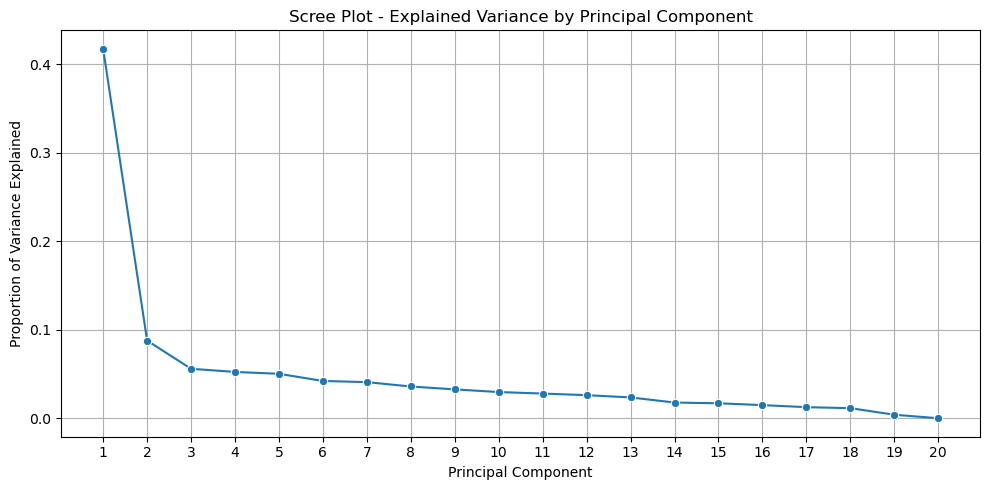

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

skillset_cols = [
     'Academic_mean',
     'Company Business_mean', 
     'skill_committee_sustainability_mean',
     'skill_committee_entrepreneurial_mean',
     'skill_committee_compensation_mean',
     'skill_committee_conglomerate_experience_mean',
     'skill_committee_hr_mean',
     'skill_committee_technology_mean',
     'skill_committee_finance_accounting_mean',
     'skill_committee_governance_mean',
     'skill_committee_government_policy_mean',
     'skill_committee_international_mean',
     'skill_committee_leadership_mean',
     'skill_committee_legal_mean',
     'skill_committee_marketing_mean',
     'skill_committee_risk_management_mean',
     'skill_committee_scientific_mean',
     'skill_committee_strategic_planning_mean',
     'skill_committee_manufacturing_supply_chain_mean',
     'skill_committee_leadership_outside_board_mean',
]

df2_pca = mainFirm.loc[mainFirm["AsOnYear"] > 2012].copy()

X = df2_pca[skillset_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=range(1, len(pca_full.explained_variance_ratio_) + 1),
    y=pca_full.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot - Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

pca = PCA(n_components=3)
principal_component = pca.fit_transform(X_scaled)

df2_pca['SkillsetIndex_skill_committee'] = principal_component[:, 0]
df2_pca['SkillsetIndex_skill_committee'] = (df2_pca['SkillsetIndex_skill_committee'] - df2_pca['SkillsetIndex_skill_committee'].mean()) / df2_pca['SkillsetIndex_skill_committee'].std()

median_value = df2_pca['SkillsetIndex_skill_committee'].median()
df2_pca['SkillsetGeneralistDummy_skill_committee'] = (df2_pca['SkillsetIndex_skill_committee'] > median_value).astype(int)

mainFirm = mainFirm.merge(
    df2_pca[['Symbol', 'AsOnDate', 'SkillsetIndex_skill_committee', 'SkillsetGeneralistDummy_skill_committee']],
    on=['Symbol', 'AsOnDate'],
    how='left'
)

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(skillset_cols))],
    index=skillset_cols
)

In [12]:
pc1_loadings = loadings[['PC1']].copy()
pc1_loadings['Skillset Feature'] = pc1_loadings.index
pc1_sorted = pc1_loadings.sort_values('PC1', ascending=False)

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_10288\365872179.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')


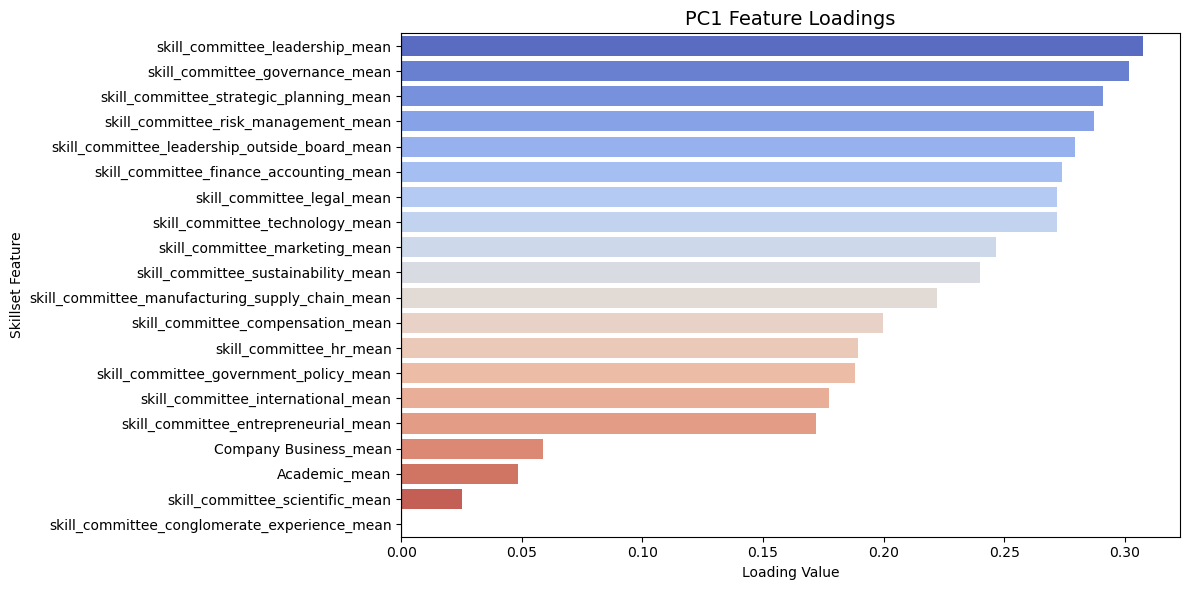

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')
plt.title('PC1 Feature Loadings', fontsize=14)
plt.xlabel('Loading Value')
plt.ylabel('Skillset Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [14]:
eigenvalue_pc1 = pca_full.explained_variance_[0]
explained_variance_ratio_pc1 = pca_full.explained_variance_ratio_[0]
cumulative_explained_variance_pc1 = pca_full.explained_variance_ratio_.cumsum()[0]

print(f"Eigenvalue for PC1: {eigenvalue_pc1:.3f}")
print(f"Explained Variance Ratio for PC1: {explained_variance_ratio_pc1 * 100:.2f}%")
print(f"Cumulative Explained Variance Ratio up to PC1: {cumulative_explained_variance_pc1 * 100:.2f}%")

loadings_pc1 = loadings['PC1'].sort_values(key=lambda x: abs(x), ascending=False)
print("\nTop PC1 Loadings:")
print(loadings_pc1.round(3).head(21))

Eigenvalue for PC1: 7.935
Explained Variance Ratio for PC1: 41.76%
Cumulative Explained Variance Ratio up to PC1: 41.76%

Top PC1 Loadings:
skill_committee_leadership_mean                    0.308
skill_committee_governance_mean                    0.302
skill_committee_strategic_planning_mean            0.291
skill_committee_risk_management_mean               0.287
skill_committee_leadership_outside_board_mean      0.279
skill_committee_finance_accounting_mean            0.274
skill_committee_legal_mean                         0.272
skill_committee_technology_mean                    0.272
skill_committee_marketing_mean                     0.246
skill_committee_sustainability_mean                0.240
skill_committee_manufacturing_supply_chain_mean    0.222
skill_committee_compensation_mean                  0.200
skill_committee_hr_mean                            0.189
skill_committee_government_policy_mean             0.188
skill_committee_international_mean                 0.177
skill

In [15]:
print("PCs with eigen value and Explained Variance:")
x = 0
cum_explained_variance = 0
for i, eigenvalue in enumerate(pca_full.explained_variance_):
    print(f"PC {i+1:<5} : {eigenvalue:<8.3f} ::: {pca_full.explained_variance_ratio_[i]*100:.2f} %")
    if eigenvalue > 1:
        x += 1
        cum_explained_variance += pca_full.explained_variance_ratio_[i]*100

print(f"\nCumulative Explained Variance of eligible PCs (eigen value > 1):")
print(f"Top {x} PCs cumulative expl variance = {cum_explained_variance:.2f}%")

PCs with eigen value and Explained Variance:
PC 1     : 7.935    ::: 41.76 %
PC 2     : 1.668    ::: 8.78 %
PC 3     : 1.063    ::: 5.59 %
PC 4     : 0.995    ::: 5.24 %
PC 5     : 0.955    ::: 5.02 %
PC 6     : 0.801    ::: 4.22 %
PC 7     : 0.776    ::: 4.08 %
PC 8     : 0.682    ::: 3.59 %
PC 9     : 0.620    ::: 3.26 %
PC 10    : 0.563    ::: 2.96 %
PC 11    : 0.530    ::: 2.79 %
PC 12    : 0.496    ::: 2.61 %
PC 13    : 0.447    ::: 2.35 %
PC 14    : 0.337    ::: 1.78 %
PC 15    : 0.321    ::: 1.69 %
PC 16    : 0.282    ::: 1.49 %
PC 17    : 0.238    ::: 1.25 %
PC 18    : 0.217    ::: 1.14 %
PC 19    : 0.076    ::: 0.40 %
PC 20    : 0.000    ::: 0.00 %

Cumulative Explained Variance of eligible PCs (eigen value > 1):
Top 3 PCs cumulative expl variance = 56.13%


In [16]:
pc1_loadings_vector = pca_full.components_[0, :]

factor_scores_raw = X_scaled @ pc1_loadings_vector

factor_scores_standardized = (factor_scores_raw - factor_scores_raw.mean()) / factor_scores_raw.std()

df2_pca['Skill_Committee_FactorScore'] = factor_scores_standardized

mainFirm = mainFirm.merge(
    df2_pca[['Symbol', 'AsOnDate', 'Skill_Committee_FactorScore']],
    on=['Symbol', 'AsOnDate'],
    how='left'
)

# PCA - combined

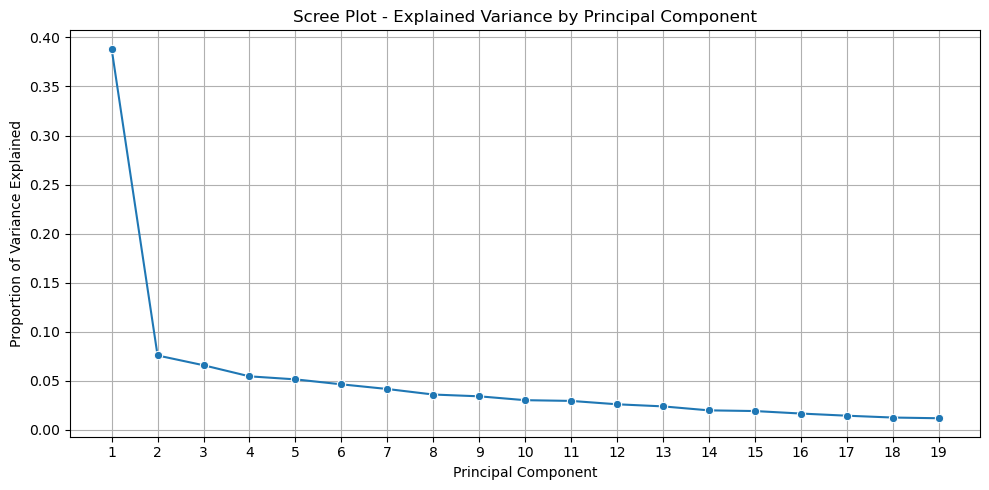

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

skillset_cols = [
     'Academic_mean',
     'Company Business_mean',
     'combined_sustainability_mean',
     'combined_entrepreneurial_mean',
     'combined_compensation_mean',
     'combined_conglomerate_experience_mean',
     'combined_hr_mean',
     'combined_technology_mean',
     'combined_finance_accounting_mean',
     'combined_governance_mean',
     'combined_government_policy_mean',
     'combined_international_mean',
     'combined_leadership_mean',
     'combined_legal_mean',
     'combined_marketing_mean',
     'combined_risk_management_mean',
     'combined_scientific_mean',
     'combined_strategic_planning_mean',
     'combined_manufacturing_supply_chain_mean',
]

df2_pca = mainFirm.loc[ mainFirm["AsOnYear"] > 2012].copy()

X = df2_pca[skillset_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=range(1, len(pca_full.explained_variance_ratio_) + 1),
    y=pca_full.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot - Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

pca = PCA(n_components=3)
principal_component = pca.fit_transform(X_scaled)

df2_pca['SkillsetIndex_combined'] = principal_component[:, 0]
df2_pca['SkillsetIndex_combined'] = (df2_pca['SkillsetIndex_combined'] - df2_pca['SkillsetIndex_combined'].mean()) / df2_pca['SkillsetIndex_combined'].std()

median_value = df2_pca['SkillsetIndex_combined'].median()
df2_pca['SkillsetGeneralistDummy_combined'] = (df2_pca['SkillsetIndex_combined'] > median_value).astype(int)

mainFirm = mainFirm.merge(
    df2_pca[['Symbol', 'AsOnDate', 'SkillsetIndex_combined', 'SkillsetGeneralistDummy_combined']],
    on=['Symbol', 'AsOnDate'],
    how='left'
)

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(skillset_cols))],
    index=skillset_cols
)

In [18]:
pc1_loadings = loadings[['PC1']].copy()
pc1_loadings['Skillset Feature'] = pc1_loadings.index
pc1_sorted = pc1_loadings.sort_values('PC1', ascending=False)

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_10288\365872179.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')


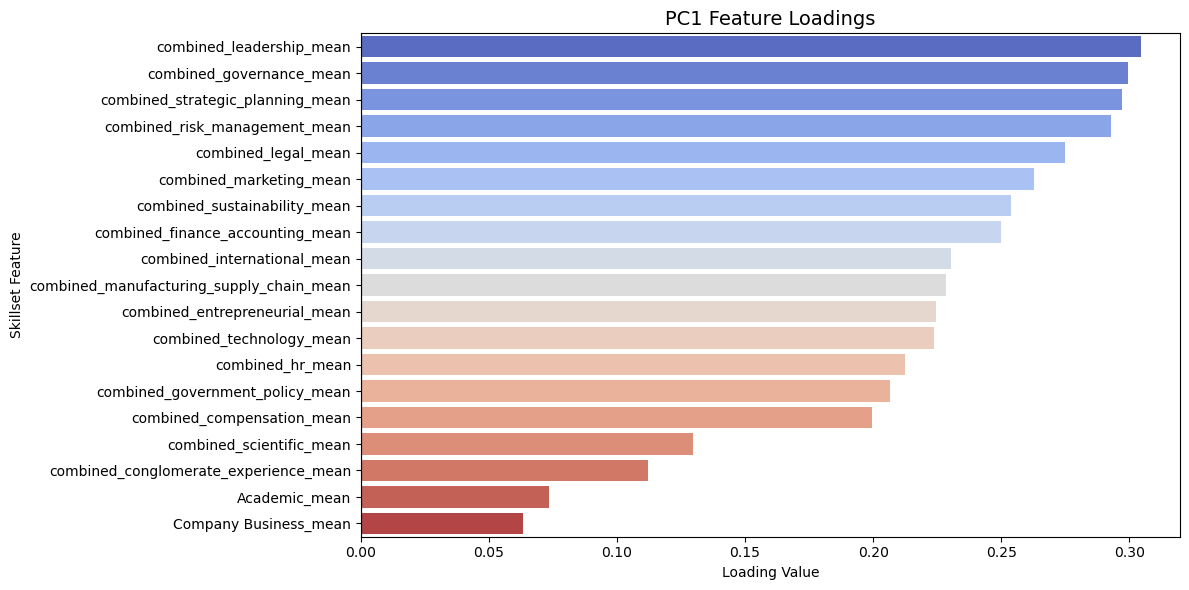

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')
plt.title('PC1 Feature Loadings', fontsize=14)
plt.xlabel('Loading Value')
plt.ylabel('Skillset Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [20]:
eigenvalue_pc1 = pca_full.explained_variance_[0]
explained_variance_ratio_pc1 = pca_full.explained_variance_ratio_[0]
cumulative_explained_variance_pc1 = pca_full.explained_variance_ratio_.cumsum()[0]

print(f"Eigenvalue for PC1: {eigenvalue_pc1:.3f}")
print(f"Explained Variance Ratio for PC1: {explained_variance_ratio_pc1 * 100:.2f}%")
print(f"Cumulative Explained Variance Ratio up to PC1: {cumulative_explained_variance_pc1 * 100:.2f}%")

loadings_pc1 = loadings['PC1'].sort_values(key=lambda x: abs(x), ascending=False)
print("\nTop PC1 Loadings:")
print(loadings_pc1.round(3).head(21))

Eigenvalue for PC1: 7.380
Explained Variance Ratio for PC1: 38.84%
Cumulative Explained Variance Ratio up to PC1: 38.84%

Top PC1 Loadings:
combined_leadership_mean                    0.305
combined_governance_mean                    0.299
combined_strategic_planning_mean            0.297
combined_risk_management_mean               0.293
combined_legal_mean                         0.275
combined_marketing_mean                     0.263
combined_sustainability_mean                0.254
combined_finance_accounting_mean            0.250
combined_international_mean                 0.230
combined_manufacturing_supply_chain_mean    0.228
combined_entrepreneurial_mean               0.224
combined_technology_mean                    0.224
combined_hr_mean                            0.212
combined_government_policy_mean             0.207
combined_compensation_mean                  0.200
combined_scientific_mean                    0.130
combined_conglomerate_experience_mean       0.112
Academic_m

In [21]:
print("PCs with eigen value and Explained Variance:")
x = 0
cum_explained_variance = 0
for i, eigenvalue in enumerate(pca_full.explained_variance_):
    print(f"PC {i+1:<5} : {eigenvalue:<8.3f} ::: {pca_full.explained_variance_ratio_[i]*100:.2f} %")
    if eigenvalue > 1:
        x += 1
        cum_explained_variance += pca_full.explained_variance_ratio_[i]*100

print(f"\nCumulative Explained Variance of eligible PCs (eigen value > 1):")
print(f"Top {x} PCs cumulative expl variance = {cum_explained_variance:.2f}%")

PCs with eigen value and Explained Variance:
PC 1     : 7.380    ::: 38.84 %
PC 2     : 1.442    ::: 7.59 %
PC 3     : 1.253    ::: 6.59 %
PC 4     : 1.038    ::: 5.46 %
PC 5     : 0.979    ::: 5.15 %
PC 6     : 0.883    ::: 4.65 %
PC 7     : 0.793    ::: 4.17 %
PC 8     : 0.686    ::: 3.61 %
PC 9     : 0.651    ::: 3.43 %
PC 10    : 0.576    ::: 3.03 %
PC 11    : 0.562    ::: 2.96 %
PC 12    : 0.497    ::: 2.61 %
PC 13    : 0.456    ::: 2.40 %
PC 14    : 0.379    ::: 2.00 %
PC 15    : 0.366    ::: 1.93 %
PC 16    : 0.318    ::: 1.67 %
PC 17    : 0.276    ::: 1.45 %
PC 18    : 0.240    ::: 1.26 %
PC 19    : 0.226    ::: 1.19 %

Cumulative Explained Variance of eligible PCs (eigen value > 1):
Top 4 PCs cumulative expl variance = 58.48%


In [22]:
pc1_loadings_vector = pca_full.components_[0, :]

factor_scores_raw = X_scaled @ pc1_loadings_vector

factor_scores_standardized = (factor_scores_raw - factor_scores_raw.mean()) / factor_scores_raw.std()

df2_pca['Combined_FactorScore'] = factor_scores_standardized

mainFirm = mainFirm.merge(
    df2_pca[['Symbol', 'AsOnDate', 'Combined_FactorScore']],
    on=['Symbol', 'AsOnDate'],
    how='left'
)

# PCA - aggregated board skill list

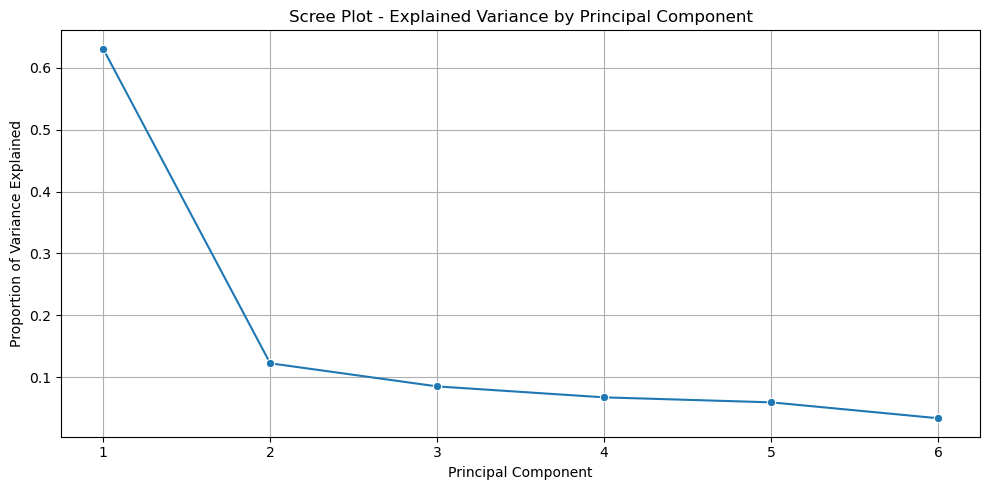

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pcaFiltered = mainFirm.loc[mainFirm["AsOnYear"] >= 2013].copy()

aggregated_cols = {
    "Finance_Risk_Governance": [
        "board_finance_mean",
        "board_accounts/audit/taxation_mean",
        "board_risk management_mean",
        "board_corporate governance_mean",
        "board_legal/compliance_mean",
        "board_strategy_mean"
    ],
    "Leadership_HR_Values": [
        "board_leadership/management_mean",
        "board_human resources_mean",
        "board_personal values_mean",
        "board_diversity_mean"
    ],
    "Tech_Operations": [
        "board_information technology_mean",
        "board_operations_mean",
        "board_supply chain management_mean",
        "board_industrials_mean"
    ],
    "Policy_Public_Social": [
        "board_public policy_mean",
        "board_corporate social responsibility_mean",
        "board_marketing_mean",
        "board_services_mean"
    ],
    "Industry_Sectoral": [
        "board_healthcare_mean",
        "board_energy_mean",
        "board_utilities_mean",
        "board_commodities_mean",
        "board_fast moving consumer goods_mean",
        "board_consumer discretionary_mean"
    ],
    "Research_Intl": [
        "board_economics_mean",
        "board_research & development_mean",
        "board_international business_mean",
        "board_telecommunication_mean",
        "board_financial services_mean",
        "board_diversified_mean"
    ]
}

for agg_name, cols in aggregated_cols.items():
    pcaFiltered[agg_name] = pcaFiltered[cols].mean(axis=1)

agg_features = list(aggregated_cols.keys())

pcaFiltered2 = pcaFiltered.copy()

pca_data = pcaFiltered2[agg_features].copy()
scaler = StandardScaler()
pca_data_scaled = scaler.fit_transform(pca_data)

pca_full = PCA()
pca_output = pca_full.fit_transform(pca_data_scaled)

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=range(1, len(pca_full.explained_variance_ratio_) + 1),
    y=pca_full.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot - Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

pca = PCA(n_components=3)
principal_component = pca.fit_transform(pca_data_scaled)

# Create uniquely named columns for this iteration
pcaFiltered2["SkillsetIndex_board_agg"] = principal_component[:, 0]
pcaFiltered2["SkillsetIndex_board_agg"] = (pcaFiltered2["SkillsetIndex_board_agg"] - pcaFiltered2["SkillsetIndex_board_agg"].mean()) / pcaFiltered2["SkillsetIndex_board_agg"].std()

median_value = pcaFiltered2["SkillsetIndex_board_agg"].median()
pcaFiltered2["SkillsetGeneralistDummy_board_agg"] = (pcaFiltered2["SkillsetIndex_board_agg"] > median_value).astype(int)

# Merge without conflict
mainFirm = mainFirm.merge(
    pcaFiltered2[["Symbol", "AsOnDate", "SkillsetIndex_board_agg", "SkillsetGeneralistDummy_board_agg"]],
    on=["Symbol", "AsOnDate"],
    how="left"
)

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f"PC{i+1}" for i in range(len(agg_features))],
    index=agg_features
)


In [24]:
loadings

,PC1,PC2,PC3,PC4,PC5,PC6
Finance_Risk_Governance,0.464256,-0.001205,-0.169307,-0.180779,-0.244664,0.814407
Leadership_HR_Values,0.441298,0.033038,-0.284091,-0.431211,-0.483144,-0.551440
Tech_Operations,0.400897,-0.366826,-0.305495,0.771087,-0.021517,-0.127886
Policy_Public_Social,0.430631,-0.047828,-0.140155,-0.293570,0.835801,-0.088764
Industry_Sectoral,0.317651,0.869820,0.195110,0.316314,0.023347,-0.062002
Research_Intl,0.377701,-0.324764,0.859994,-0.023731,-0.084497,-0.067659


In [25]:
pc1_loadings = loadings[["PC1"]].copy()
pc1_loadings["Skillset Feature"] = pc1_loadings.index
pc1_sorted = pc1_loadings.sort_values("PC1", ascending=False)

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_10288\2481851606.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="PC1", y="Skillset Feature", data=pc1_sorted, palette="coolwarm")


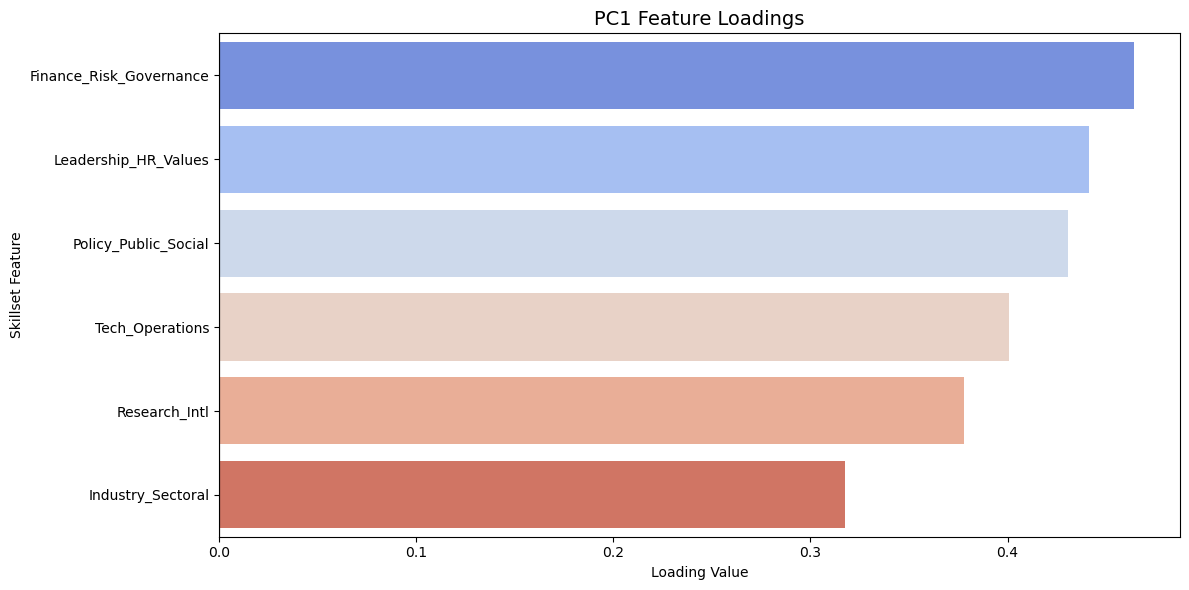

In [26]:
plt.figure(figsize=(12, 6))
sns.barplot(x="PC1", y="Skillset Feature", data=pc1_sorted, palette="coolwarm")
plt.title("PC1 Feature Loadings", fontsize=14)
plt.xlabel("Loading Value")
plt.ylabel("Skillset Feature")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


In [27]:
eigenvalue_pc1 = pca_full.explained_variance_[0]
explained_variance_ratio_pc1 = pca_full.explained_variance_ratio_[0]
cumulative_explained_variance_pc1 = pca_full.explained_variance_ratio_.cumsum()[0]

print(f"Eigenvalue for PC1: {eigenvalue_pc1:.3f}")
print(f"Explained Variance Ratio for PC1: {explained_variance_ratio_pc1 * 100:.2f}%")
print(f"Cumulative Explained Variance Ratio up to PC1: {cumulative_explained_variance_pc1 * 100:.2f}%")

loadings_pc1 = loadings["PC1"].sort_values(key=lambda x: abs(x), ascending=False)
print("\nTop PC1 Loadings:")
print(loadings_pc1.round(3).head(21))


Eigenvalue for PC1: 3.783
Explained Variance Ratio for PC1: 63.04%
Cumulative Explained Variance Ratio up to PC1: 63.04%

Top PC1 Loadings:
Finance_Risk_Governance    0.464
Leadership_HR_Values       0.441
Policy_Public_Social       0.431
Tech_Operations            0.401
Research_Intl              0.378
Industry_Sectoral          0.318
Name: PC1, dtype: float64


In [28]:
print("PCs with eigen value and Explained Variance:")
x = 0
cum_explained_variance = 0
for i, eigenvalue in enumerate(pca_full.explained_variance_):
    print(f"PC {i+1:<5} : {eigenvalue:<8.3f} ::: {pca_full.explained_variance_ratio_[i]*100:.2f} %")
    if eigenvalue > 1:
        x += 1
        cum_explained_variance += pca_full.explained_variance_ratio_[i]*100

print(f"\nCumulative Explained Variance of eligible PCs (eigen value > 1):")
print(f"Top {x} PCs cumulative expl variance = {cum_explained_variance:.2f}%")

PCs with eigen value and Explained Variance:
PC 1     : 3.783    ::: 63.04 %
PC 2     : 0.736    ::: 12.27 %
PC 3     : 0.513    ::: 8.54 %
PC 4     : 0.406    ::: 6.77 %
PC 5     : 0.358    ::: 5.97 %
PC 6     : 0.204    ::: 3.40 %

Cumulative Explained Variance of eligible PCs (eigen value > 1):
Top 1 PCs cumulative expl variance = 63.04%


In [29]:
pc1_loadings_vector = pca_full.components_[0, :]

factor_scores_raw = pca_data @ pc1_loadings_vector

factor_scores_standardized = (factor_scores_raw - factor_scores_raw.mean()) / factor_scores_raw.std()

pcaFiltered2["Board_FactorScore"] = factor_scores_standardized

mainFirm = mainFirm.merge(
    pcaFiltered2[["Symbol", "AsOnDate", "Board_FactorScore"]],
    on=["Symbol", "AsOnDate"],
    how="left"
)


In [30]:
mainFirm.columns.to_list()

['FirmID',
 'Symbol',
 'AsOnDate',
 'TotDirCount',
 'AsOnYear',
 'LnBoardSize',
 'FemaleDirCount',
 'PercentWomenDir',
 'Women_dummy',
 'AvgAge',
 'CountRookie',
 'Rookie_dummy',
 'CountNonRookie',
 'CountIndep',
 'PercentIndep',
 'CountNonIndep',
 'CountRookieIndep',
 'CountRookieNonIndep',
 'CountNonRookieIndep',
 'CountNonRookieNonIndep',
 'CountPromoterDir',
 'CountBusyDir',
 'PercentBusyDir',
 'Busy_dummy',
 'HasCeoMD',
 'HasChairman',
 'HasPromoterOnBoard',
 'HasDualityChairmanMD',
 'IsFamilyManaged',
 'HasFamilyChairman',
 'HasFamilyChairmanAndCEO',
 'CountFirstTermDir',
 'CountFirstTermIndepDir',
 'PercentFirstTermIndepDir',
 'CountTurnOverIndepDir',
 'HasIndepTurnOver',
 'AvgTenureInYearsinCompTotal',
 'AvgTenureInYearsinCompIndep',
 'AvgTenureInYearsTotal',
 'PercentRookieIndep',
 'PercentNonRookieIndep',
 'PercentRookieNonIndep',
 'PercentNonRookieNonIndep',
 'PercentRookie',
 'PercentNonRookie',
 'IsRookieBoard',
 'JustOneRookie',
 'TwoOrMoreRookies',
 'CountMBA',
 'Percent

In [31]:
import pandas as pd

business_segments = pd.read_csv(rf"{supporting_folder_path}\CMIE segments.csv", skiprows=4)
business_segments = business_segments.rename(columns={
    business_segments.columns[0]: "Firm",          
    business_segments.columns[1]: "Segment",       
    business_segments.columns[4]: "Date"          
})

business_segments = business_segments.dropna(subset=["Firm", "Segment", "Date"])

business_segments["Year"] = pd.to_datetime(business_segments["Date"], format = "%d-%m-%Y", errors="coerce").dt.year

business_segments = business_segments.dropna(subset=["Year"])

segment_count = business_segments.groupby(["Firm", "Year"])["Segment"].nunique().reset_index()

segment_count = segment_count.rename(columns={"Segment": "Number of Segments"})

In [32]:
segment_count

,Firm,Year,Number of Segments
0,10I Commerce Services Pvt. Ltd.,2022,1
1,3I Infotech Ltd.,2019,1
2,63 Moons Technologies Ltd.,2013,1
3,63 Moons Technologies Ltd.,2014,1
4,63 Moons Technologies Ltd.,2015,1
...,...,...,...
6667,Zoom Leasing & Finance Co. Ltd.,2011,1
6668,Zoom Leasing & Finance Co. Ltd.,2012,1
6669,Zuari Maroc Phosphates Pvt. Ltd.,2010,1
6670,Zuari Maroc Phosphates Pvt. Ltd.,2011,1


In [33]:
mainFirm = pd.merge(mainFirm, segment_count, 
                     left_on=["Company Name", "AsOnYear"], 
                     right_on=["Firm", "Year"], 
                     how="left")

mainFirm = mainFirm.drop(["Firm", "Year"], axis=1)
mainFirm["Number of Segments"] = mainFirm["Number of Segments"].fillna(1).astype(int)

In [34]:
mainFirm

,FirmID,Symbol,AsOnDate,TotDirCount,AsOnYear,LnBoardSize,FemaleDirCount,PercentWomenDir,Women_dummy,AvgAge,CountRookie,Rookie_dummy,CountNonRookie,CountIndep,PercentIndep,CountNonIndep,CountRookieIndep,CountRookieNonIndep,CountNonRookieIndep,CountNonRookieNonIndep,CountPromoterDir,CountBusyDir,PercentBusyDir,Busy_dummy,HasCeoMD,HasChairman,HasPromoterOnBoard,HasDualityChairmanMD,IsFamilyManaged,HasFamilyChairman,HasFamilyChairmanAndCEO,CountFirstTermDir,CountFirstTermIndepDir,PercentFirstTermIndepDir,CountTurnOverIndepDir,HasIndepTurnOver,AvgTenureInYearsinCompTotal,AvgTenureInYearsinCompIndep,AvgTenureInYearsTotal,PercentRookieIndep,PercentNonRookieIndep,PercentRookieNonIndep,PercentNonRookieNonIndep,PercentRookie,PercentNonRookie,IsRookieBoard,JustOneRookie,TwoOrMoreRookies,CountMBA,PercentMBA,CountIndepMBA,PercentIndepMBA,CountRookieIndepMBA,PercentRookieIndepMBA,CountPhD,PercentPhD,CountIndepPhD,PercentIndepPhD,CountRookieIndepPhD,PercentRookieIndepPhD,CountFinanceXP,PercentFinanceXP,CountIndepFinanceXP,PercentIndepFinanceXP,CountRookieIndepFinanceXP,PercentRookieIndepFinanceXP,CountTechXP,PercentTechXP,CountIndepTechXP,PercentIndepTechXP,CountRookieIndepTechXP,PercentRookieIndepTechXP,CountFinanceSkill,PercentFinanceSkill,CountIndepFinanceSkill,PercentIndepFinanceSkill,CountRookieIndepFinanceSkill,PercentRookieIndepFinanceSkill,CountTechSkill,PercentTechSkill,CountIndepTechSkill,PercentIndepTechSkill,CountRookieIndepTechSkill,PercentRookieIndepTechSkill,CountRelatedIndustryXP,PercentRelatedIndustryXP,CountIndepRelatedIndustryXP,PercentIndepRelatedIndustryXP,CountRookieIndepRelatedIndustryXP,PercentRookieIndepRelatedIndustryXP,CountExecXP,PercentExecXP,CountIndepExecXP,PercentIndepExecXP,CountRookieIndepExecXP,PercentRookieIndepExecXP,CountPublicExecXP,PercentPublicExecXP,CountIndepPublicExecXP,PercentIndepPublicExecXP,CountRookieIndepPublicExecXP,PercentRookieIndepPublicExecXP,CountPrivateExecXP,PercentPrivateExecXP,CountIndepPrivateExecXP,PercentIndepPrivateExecXP,CountRookieIndepPrivateExecXP,PercentRookieIndepPrivateExecXP,CountCeoMDChairXP,PercentCeoMDChairXP,CountIndepCeoMDChairXP,PercentIndepCeoMDChairXP,CountRookieIndepCeoMDChairXP,PercentRookieIndepCeoMDChairXP,CountRookieAppoint,CountRookieIndepAppoint,CountNonRookieAppoint,CountNonRookieIndepAppoint,RookieAppointDummy,RookieIndepAppointDummy,NonRookieAppointDummy,NonRookieIndepAppointDummy,TotalDirCess,TotalRookieIndepDirCess,TotalDirAppoint,TotalRookieIndepDirAppoint,UniqueSkills,CountUniqueSkills,CountRetiringTermLimit,PercentRetiringTermLimit,TermLimitRetireesPcodeList,CountDirTurnOver_exits_retire,PercentDirTurnOver_exits_retire,CountDirTurnOver_real_exits,PercentDirTurnOver_real_exits,CountIndepDirTurnOver_exits_retire,PercentIndepDirTurnOver_exits_retire,CountIndepDirTurnOver_real_exits,PercentIndepDirTurnOver_real_exits,ZeroYearPCodeList,FirstYearPCodeList,TwoYearPCodeList,ThreeYearPCodeList,PCodeList,ZeroYearIndepPCodeList,FirstYearIndepPCodeList,TwoYearIndepPCodeList,ThreeYearIndepPCodeList,IndepPCodeList,BoardAbsenceMean,Academic_mean,Company Business_mean,combined_sustainability_mean,combined_entrepreneurial_mean,combined_compensation_mean,combined_conglomerate_experience_mean,combined_hr_mean,combined_technology_mean,combined_finance_accounting_mean,combined_governance_mean,combined_government_policy_mean,combined_international_mean,combined_leadership_mean,combined_legal_mean,combined_marketing_mean,combined_risk_management_mean,combined_scientific_mean,combined_strategic_planning_mean,combined_manufacturing_supply_chain_mean,combined_leadership_outside_board_mean,skilllist_sustainability_mean,skilllist_entrepreneurial_mean,skilllist_compensation_mean,skilllist_conglomerate_experience_mean,skilllist_hr_mean,skilllist_technology_mean,skilllist_finance_accounting_mean,skilllist_governance_mean,skilllist_government_policy_mean,skilllist_international_mean,skilllist_leadership_mean,skilllist_legal_mean,skilllist_marketing_mean,skilllist_risk_management_

In [35]:
mainFirm["Number of Segments"].value_counts()

Number of Segments
1    28872
2       28
4        7
3        2
Name: count, dtype: int64

# PCA - aggregated board skill list

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

pcaFiltered = mainFirm.loc[mainFirm["AsOnYear"] >= 2013].copy()

skillset_cols = [
    "board_consumer discretionary_mean",
    "board_research & development_mean",
    "board_legal/compliance_mean",
    "board_utilities_mean",
    "board_healthcare_mean",
    "board_fast moving consumer goods_mean",
    "board_risk management_mean",
    "board_economics_mean",
    "board_supply chain management_mean",
    "board_diversified_mean",
    "board_personal values_mean",
    "board_finance_mean",
    "board_diversity_mean",
    "board_telecommunication_mean",
    "board_leadership/management_mean",
    "board_energy_mean",
    "board_industrials_mean",
    "board_human resources_mean",
    "board_services_mean",
    "board_corporate governance_mean",
    "board_accounts/audit/taxation_mean",
    "board_operations_mean",
    "board_financial services_mean",
    "board_commodities_mean",
    "board_corporate social responsibility_mean",
    "board_strategy_mean",
    "board_international business_mean",
    "board_information technology_mean",
    "board_marketing_mean",
    "board_public policy_mean",
]

pcaFeatures = pcaFiltered.loc[:, skillset_cols].copy()

pcaFeatures_T = pcaFeatures.T

scaler = StandardScaler()
X_features_scaled = scaler.fit_transform(pcaFeatures_T)

k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
feature_clusters = kmeans.fit_predict(X_features_scaled)


feature_cluster_map = pd.DataFrame({
    "Feature": pcaFeatures_T.index,
    "Cluster": feature_clusters
}).sort_values("Cluster")

cluster_groups = feature_cluster_map.groupby("Cluster")["Feature"].apply(list)

for i, cols in cluster_groups.items():
    mainFirm[f"Cluster_{i}_mean"] = mainFirm[cols].mean(axis=1)

print("Clustering result:")
print(feature_cluster_map)

Clustering result:
                                       Feature  Cluster
14            board_leadership/management_mean        0
25                         board_strategy_mean        0
19             board_corporate governance_mean        0
11                          board_finance_mean        0
16                      board_industrials_mean        1
22               board_financial services_mean        2
18                         board_services_mean        2
15                           board_energy_mean        2
13                board_telecommunication_mean        2
23                      board_commodities_mean        2
12                        board_diversity_mean        2
9                       board_diversified_mean        2
8           board_supply chain management_mean        2
7                         board_economics_mean        2
5        board_fast moving consumer goods_mean        2
4                        board_healthcare_mean        2
3                         boa

C:\Users\SHIVAM\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


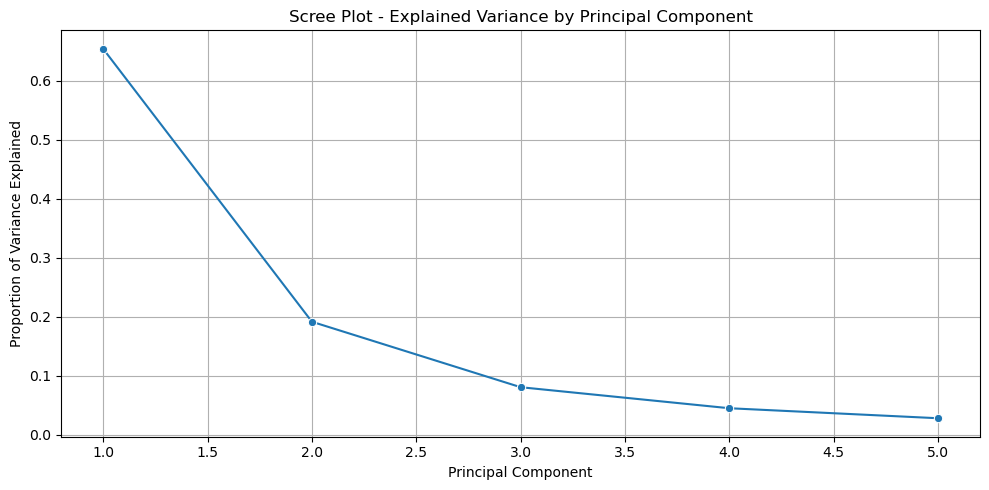

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_10288\768117170.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PC1', y='Cluster', data=pc1_sorted, palette='coolwarm')


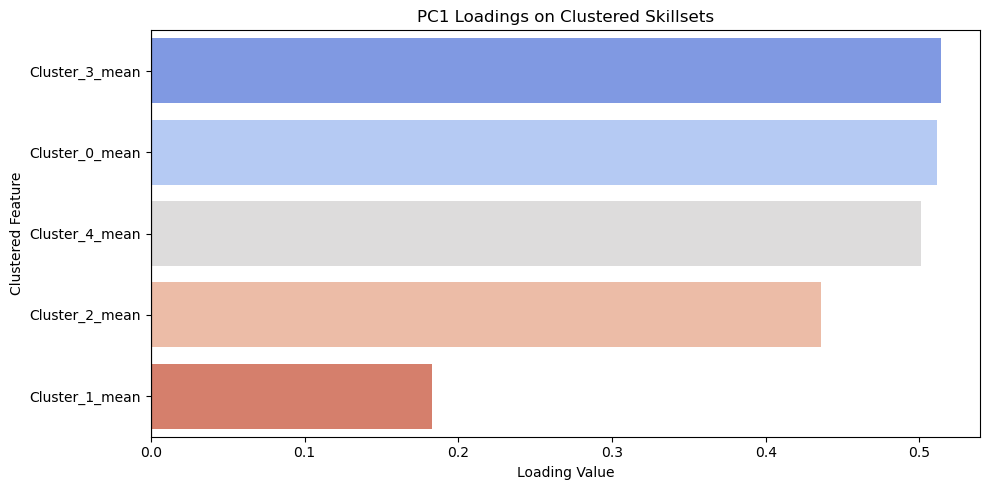

Eigenvalue for PC1: 3.272
Explained Variance Ratio for PC1: 65.43%
Cumulative Explained Variance up to PC1: 65.43%


In [37]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

cluster_features = [col for col in mainFirm.columns if col.startswith('Cluster_') and col.endswith('_mean')]
df2_pca = mainFirm.dropna(subset=cluster_features).copy()

X = df2_pca[cluster_features]
X_scaled = StandardScaler().fit_transform(X)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# Scree plot
plt.figure(figsize=(10, 5))
sns.lineplot(
    x=range(1, len(pca_full.explained_variance_ratio_) + 1),
    y=pca_full.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot - Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.grid(True)
plt.tight_layout()
plt.show()

pca = PCA(n_components=3)
principal_component = pca.fit_transform(X_scaled)

df2_pca['SkillsetIndex_board_cluster'] = principal_component[:, 0]
df2_pca['SkillsetIndex_board_cluster'] = (df2_pca['SkillsetIndex_board_cluster'] - df2_pca['SkillsetIndex_board_cluster'].mean()) / df2_pca['SkillsetIndex_board_cluster'].std()

median_value = df2_pca['SkillsetIndex_board_cluster'].median()
df2_pca['SkillsetGeneralistDummy_board_cluster'] = (df2_pca['SkillsetIndex_board_cluster'] > median_value).astype(int)

mainFirm = mainFirm.merge(
    df2_pca[['Symbol', 'AsOnDate', 'SkillsetIndex_board_cluster', 'SkillsetGeneralistDummy_board_cluster']],
    on=['Symbol', 'AsOnDate'],
    how='left'
)

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(cluster_features))],
    index=cluster_features
)

pc1_sorted = loadings[['PC1']].copy()
pc1_sorted['Cluster'] = pc1_sorted.index
pc1_sorted = pc1_sorted.sort_values('PC1', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='PC1', y='Cluster', data=pc1_sorted, palette='coolwarm')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('PC1 Loadings on Clustered Skillsets')
plt.xlabel('Loading Value')
plt.ylabel('Clustered Feature')
plt.tight_layout()
plt.show()

print(f"Eigenvalue for PC1: {pca_full.explained_variance_[0]:.3f}")
print(f"Explained Variance Ratio for PC1: {pca_full.explained_variance_ratio_[0] * 100:.2f}%")
print(f"Cumulative Explained Variance up to PC1: {pca_full.explained_variance_ratio_.cumsum()[0] * 100:.2f}%")


In [38]:
mainFirm

,FirmID,Symbol,AsOnDate,TotDirCount,AsOnYear,LnBoardSize,FemaleDirCount,PercentWomenDir,Women_dummy,AvgAge,CountRookie,Rookie_dummy,CountNonRookie,CountIndep,PercentIndep,CountNonIndep,CountRookieIndep,CountRookieNonIndep,CountNonRookieIndep,CountNonRookieNonIndep,CountPromoterDir,CountBusyDir,PercentBusyDir,Busy_dummy,HasCeoMD,HasChairman,HasPromoterOnBoard,HasDualityChairmanMD,IsFamilyManaged,HasFamilyChairman,HasFamilyChairmanAndCEO,CountFirstTermDir,CountFirstTermIndepDir,PercentFirstTermIndepDir,CountTurnOverIndepDir,HasIndepTurnOver,AvgTenureInYearsinCompTotal,AvgTenureInYearsinCompIndep,AvgTenureInYearsTotal,PercentRookieIndep,PercentNonRookieIndep,PercentRookieNonIndep,PercentNonRookieNonIndep,PercentRookie,PercentNonRookie,IsRookieBoard,JustOneRookie,TwoOrMoreRookies,CountMBA,PercentMBA,CountIndepMBA,PercentIndepMBA,CountRookieIndepMBA,PercentRookieIndepMBA,CountPhD,PercentPhD,CountIndepPhD,PercentIndepPhD,CountRookieIndepPhD,PercentRookieIndepPhD,CountFinanceXP,PercentFinanceXP,CountIndepFinanceXP,PercentIndepFinanceXP,CountRookieIndepFinanceXP,PercentRookieIndepFinanceXP,CountTechXP,PercentTechXP,CountIndepTechXP,PercentIndepTechXP,CountRookieIndepTechXP,PercentRookieIndepTechXP,CountFinanceSkill,PercentFinanceSkill,CountIndepFinanceSkill,PercentIndepFinanceSkill,CountRookieIndepFinanceSkill,PercentRookieIndepFinanceSkill,CountTechSkill,PercentTechSkill,CountIndepTechSkill,PercentIndepTechSkill,CountRookieIndepTechSkill,PercentRookieIndepTechSkill,CountRelatedIndustryXP,PercentRelatedIndustryXP,CountIndepRelatedIndustryXP,PercentIndepRelatedIndustryXP,CountRookieIndepRelatedIndustryXP,PercentRookieIndepRelatedIndustryXP,CountExecXP,PercentExecXP,CountIndepExecXP,PercentIndepExecXP,CountRookieIndepExecXP,PercentRookieIndepExecXP,CountPublicExecXP,PercentPublicExecXP,CountIndepPublicExecXP,PercentIndepPublicExecXP,CountRookieIndepPublicExecXP,PercentRookieIndepPublicExecXP,CountPrivateExecXP,PercentPrivateExecXP,CountIndepPrivateExecXP,PercentIndepPrivateExecXP,CountRookieIndepPrivateExecXP,PercentRookieIndepPrivateExecXP,CountCeoMDChairXP,PercentCeoMDChairXP,CountIndepCeoMDChairXP,PercentIndepCeoMDChairXP,CountRookieIndepCeoMDChairXP,PercentRookieIndepCeoMDChairXP,CountRookieAppoint,CountRookieIndepAppoint,CountNonRookieAppoint,CountNonRookieIndepAppoint,RookieAppointDummy,RookieIndepAppointDummy,NonRookieAppointDummy,NonRookieIndepAppointDummy,TotalDirCess,TotalRookieIndepDirCess,TotalDirAppoint,TotalRookieIndepDirAppoint,UniqueSkills,CountUniqueSkills,CountRetiringTermLimit,PercentRetiringTermLimit,TermLimitRetireesPcodeList,CountDirTurnOver_exits_retire,PercentDirTurnOver_exits_retire,CountDirTurnOver_real_exits,PercentDirTurnOver_real_exits,CountIndepDirTurnOver_exits_retire,PercentIndepDirTurnOver_exits_retire,CountIndepDirTurnOver_real_exits,PercentIndepDirTurnOver_real_exits,ZeroYearPCodeList,FirstYearPCodeList,TwoYearPCodeList,ThreeYearPCodeList,PCodeList,ZeroYearIndepPCodeList,FirstYearIndepPCodeList,TwoYearIndepPCodeList,ThreeYearIndepPCodeList,IndepPCodeList,BoardAbsenceMean,Academic_mean,Company Business_mean,combined_sustainability_mean,combined_entrepreneurial_mean,combined_compensation_mean,combined_conglomerate_experience_mean,combined_hr_mean,combined_technology_mean,combined_finance_accounting_mean,combined_governance_mean,combined_government_policy_mean,combined_international_mean,combined_leadership_mean,combined_legal_mean,combined_marketing_mean,combined_risk_management_mean,combined_scientific_mean,combined_strategic_planning_mean,combined_manufacturing_supply_chain_mean,combined_leadership_outside_board_mean,skilllist_sustainability_mean,skilllist_entrepreneurial_mean,skilllist_compensation_mean,skilllist_conglomerate_experience_mean,skilllist_hr_mean,skilllist_technology_mean,skilllist_finance_accounting_mean,skilllist_governance_mean,skilllist_government_policy_mean,skilllist_international_mean,skilllist_leadership_mean,skilllist_legal_mean,skilllist_marketing_mean,skilllist_risk_management_

In [39]:
pc1_loadings_vector = pca_full.components_[0, :]

factor_scores_raw = X_scaled @ pc1_loadings_vector

factor_scores_standardized = (factor_scores_raw - factor_scores_raw.mean()) / factor_scores_raw.std()

df2_pca['Cluster_FactorScore'] = factor_scores_standardized

mainFirm = mainFirm.merge(
    df2_pca[['Symbol', 'AsOnDate', 'Cluster_FactorScore']],
    on=['Symbol', 'AsOnDate'],
    how='left'
)

In [40]:
mainFirm

,FirmID,Symbol,AsOnDate,TotDirCount,AsOnYear,LnBoardSize,FemaleDirCount,PercentWomenDir,Women_dummy,AvgAge,CountRookie,Rookie_dummy,CountNonRookie,CountIndep,PercentIndep,CountNonIndep,CountRookieIndep,CountRookieNonIndep,CountNonRookieIndep,CountNonRookieNonIndep,CountPromoterDir,CountBusyDir,PercentBusyDir,Busy_dummy,HasCeoMD,HasChairman,HasPromoterOnBoard,HasDualityChairmanMD,IsFamilyManaged,HasFamilyChairman,HasFamilyChairmanAndCEO,CountFirstTermDir,CountFirstTermIndepDir,PercentFirstTermIndepDir,CountTurnOverIndepDir,HasIndepTurnOver,AvgTenureInYearsinCompTotal,AvgTenureInYearsinCompIndep,AvgTenureInYearsTotal,PercentRookieIndep,PercentNonRookieIndep,PercentRookieNonIndep,PercentNonRookieNonIndep,PercentRookie,PercentNonRookie,IsRookieBoard,JustOneRookie,TwoOrMoreRookies,CountMBA,PercentMBA,CountIndepMBA,PercentIndepMBA,CountRookieIndepMBA,PercentRookieIndepMBA,CountPhD,PercentPhD,CountIndepPhD,PercentIndepPhD,CountRookieIndepPhD,PercentRookieIndepPhD,CountFinanceXP,PercentFinanceXP,CountIndepFinanceXP,PercentIndepFinanceXP,CountRookieIndepFinanceXP,PercentRookieIndepFinanceXP,CountTechXP,PercentTechXP,CountIndepTechXP,PercentIndepTechXP,CountRookieIndepTechXP,PercentRookieIndepTechXP,CountFinanceSkill,PercentFinanceSkill,CountIndepFinanceSkill,PercentIndepFinanceSkill,CountRookieIndepFinanceSkill,PercentRookieIndepFinanceSkill,CountTechSkill,PercentTechSkill,CountIndepTechSkill,PercentIndepTechSkill,CountRookieIndepTechSkill,PercentRookieIndepTechSkill,CountRelatedIndustryXP,PercentRelatedIndustryXP,CountIndepRelatedIndustryXP,PercentIndepRelatedIndustryXP,CountRookieIndepRelatedIndustryXP,PercentRookieIndepRelatedIndustryXP,CountExecXP,PercentExecXP,CountIndepExecXP,PercentIndepExecXP,CountRookieIndepExecXP,PercentRookieIndepExecXP,CountPublicExecXP,PercentPublicExecXP,CountIndepPublicExecXP,PercentIndepPublicExecXP,CountRookieIndepPublicExecXP,PercentRookieIndepPublicExecXP,CountPrivateExecXP,PercentPrivateExecXP,CountIndepPrivateExecXP,PercentIndepPrivateExecXP,CountRookieIndepPrivateExecXP,PercentRookieIndepPrivateExecXP,CountCeoMDChairXP,PercentCeoMDChairXP,CountIndepCeoMDChairXP,PercentIndepCeoMDChairXP,CountRookieIndepCeoMDChairXP,PercentRookieIndepCeoMDChairXP,CountRookieAppoint,CountRookieIndepAppoint,CountNonRookieAppoint,CountNonRookieIndepAppoint,RookieAppointDummy,RookieIndepAppointDummy,NonRookieAppointDummy,NonRookieIndepAppointDummy,TotalDirCess,TotalRookieIndepDirCess,TotalDirAppoint,TotalRookieIndepDirAppoint,UniqueSkills,CountUniqueSkills,CountRetiringTermLimit,PercentRetiringTermLimit,TermLimitRetireesPcodeList,CountDirTurnOver_exits_retire,PercentDirTurnOver_exits_retire,CountDirTurnOver_real_exits,PercentDirTurnOver_real_exits,CountIndepDirTurnOver_exits_retire,PercentIndepDirTurnOver_exits_retire,CountIndepDirTurnOver_real_exits,PercentIndepDirTurnOver_real_exits,ZeroYearPCodeList,FirstYearPCodeList,TwoYearPCodeList,ThreeYearPCodeList,PCodeList,ZeroYearIndepPCodeList,FirstYearIndepPCodeList,TwoYearIndepPCodeList,ThreeYearIndepPCodeList,IndepPCodeList,BoardAbsenceMean,Academic_mean,Company Business_mean,combined_sustainability_mean,combined_entrepreneurial_mean,combined_compensation_mean,combined_conglomerate_experience_mean,combined_hr_mean,combined_technology_mean,combined_finance_accounting_mean,combined_governance_mean,combined_government_policy_mean,combined_international_mean,combined_leadership_mean,combined_legal_mean,combined_marketing_mean,combined_risk_management_mean,combined_scientific_mean,combined_strategic_planning_mean,combined_manufacturing_supply_chain_mean,combined_leadership_outside_board_mean,skilllist_sustainability_mean,skilllist_entrepreneurial_mean,skilllist_compensation_mean,skilllist_conglomerate_experience_mean,skilllist_hr_mean,skilllist_technology_mean,skilllist_finance_accounting_mean,skilllist_governance_mean,skilllist_government_policy_mean,skilllist_international_mean,skilllist_leadership_mean,skilllist_legal_mean,skilllist_marketing_mean,skilllist_risk_management_

## Output

In [43]:
mainFirm.to_pickle(rf"{output_folder_path}\Main_Firm_COMPLETE_Master_FactorScore.pkl")

In [44]:
mainFirm2 = mainFirm.copy()

listCol = [
    "ZeroYearPCodeList", "FirstYearPCodeList", "TwoYearPCodeList", "ThreeYearPCodeList", "PCodeList",
    "ZeroYearIndepPCodeList", "FirstYearIndepPCodeList", "TwoYearIndepPCodeList", "ThreeYearIndepPCodeList", "IndepPCodeList",
    "OtherZeroYearIndepPCode", "OtherFirstYearIndepPCode", "OtherTwoYearIndepPCode", "OtherThreeYearIndepPCode", "TotalIndepPCode",
    "OtherZeroYearPCode", "OtherFirstYearPCode", "OtherTwoYearPCode", "OtherThreeYearPCode", "TotalPCode",
    "OtherZeroYearPCodeIndepExcl", "OtherFirstYearPCodeIndepExcl", "OtherTwoYearPCodeIndepExcl", "OtherThreeYearPCodeIndepExcl", "TotalPCodeIndepExcl",
    "OtherZeroYearPCodeExcl", "OtherFirstYearPCodeExcl", "OtherTwoYearPCodeExcl", "OtherThreeYearPCodeExcl", "TotalPCodeExcl"
]

mainFirm2 = mainFirm2.drop(listCol, axis = 1)

mainFirm2.to_csv(rf"{output_folder_path}\Main_Firm_COMPLETE_Master_FactorScore v060725.csv")